In [76]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np 
import matplotlib.pyplot as plt 

In [58]:
df = pd.read_csv("D:\\AIML_SEM6\\LinearRegression\\SalaryMulti.csv")

In [59]:
df.head(5)

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
0,7,2,4,1,77318.070547
1,4,0,2,3,64951.950980
2,13,4,8,3,106058.185204
3,11,3,2,1,89649.944851
4,8,1,6,3,82206.019687


In [60]:
df.columns

Index(['Total Experience', 'Team Lead Experience',
       'Project Manager Experience', 'Certifications', 'Salary'],
      dtype='str')

**The column names are examined to identify the available features and the target variable.**

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Total Experience            1000 non-null   int64  
 1   Team Lead Experience        1000 non-null   int64  
 2   Project Manager Experience  1000 non-null   int64  
 3   Certifications              1000 non-null   int64  
 4   Salary                      1000 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


In [62]:
df.isnull().sum()

Total Experience              0
Team Lead Experience          0
Project Manager Experience    0
Certifications                0
Salary                        0
dtype: int64

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df.select_dtypes(include='number').corr()['Salary'].sort_values(ascending=False)


Salary                        1.000000
Total Experience              0.941849
Team Lead Experience          0.753772
Project Manager Experience    0.405786
Certifications                0.009678
Name: Salary, dtype: float64

### Correlation Analysis

Correlation is used to examine the relationship between the numerical input features and the target variable, `salary_package_lpa`.

A higher positive correlation indicates that the feature tends to increase along with the target, while a negative correlation indicates an inverse relationship.

In [65]:
X = df[['Total Experience', 'Team Lead Experience',
       'Project Manager Experience', 'Certifications']]
y = df['Salary']

In [66]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 2 ,test_size=0.2)

In [67]:
lr = LinearRegression()
model = lr.fit(X_train,y_train.values.reshape(-1,1))
y_pred = lr.predict(X_test)




In [68]:
df.shape

(1000, 5)

In [69]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("\n--- Model Performance ---")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)
print("adjusted_r2:", adjusted_r2)



--- Model Performance ---
Mean Absolute Error (MAE): 4153.874451525008
Mean Squared Error (MSE): 27588967.0289456
Root Mean Squared Error (RMSE): 5252.520064592386
R2 Score: 0.9192551542838039
adjusted_r2: 0.9175988497562921


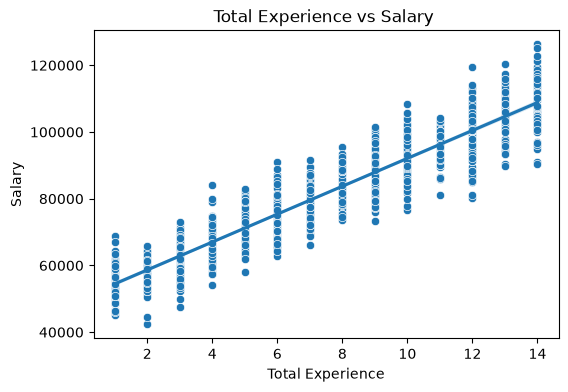

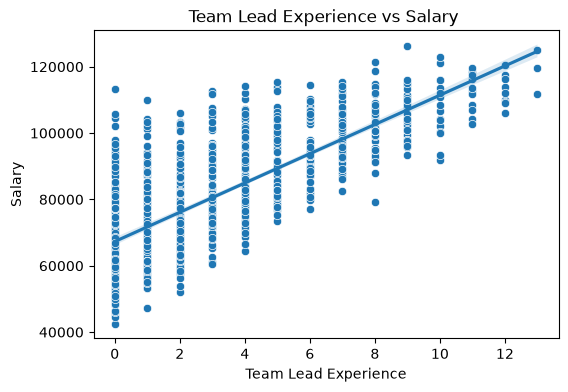

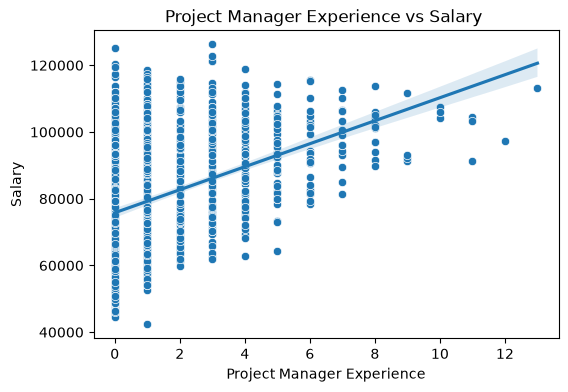

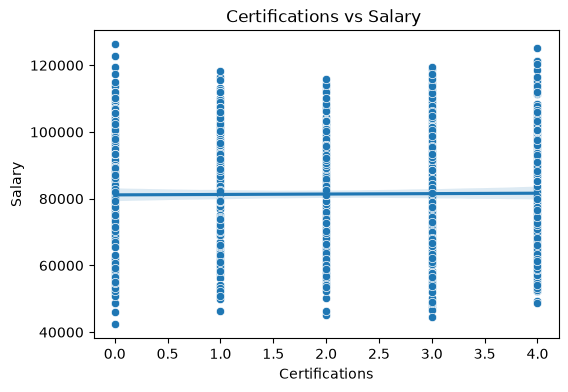

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Total Experience', 'Team Lead Experience',
       'Project Manager Experience', 'Certifications']


for feature in features:
    plt.figure(figsize=(6, 4))

    sns.scatterplot(
        data=df,
        x=feature,
        y='Salary'
    )

    sns.regplot(
        data=df,
        x=feature,
        y='Salary',
        scatter=False
    )

    plt.title(f'{feature} vs Salary ')
    plt.show()